In [38]:
import pandas as pd
import importlib
import os
import sys
sys.path.append(os.path.abspath('..'))
import func
importlib.reload(func)
from func import cal_buoyancy
import glob
import os
import re
import datetime
import metpy.calc as mpcalc
from metpy.calc import dewpoint_from_specific_humidity, mixed_parcel, specific_humidity_from_dewpoint, lfc
from metpy.units import units
import metpy.constants as mpconsts
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from scipy.interpolate import interp1d
from scipy.optimize import bisect
import numpy as np
import pickle
import numpy as np
import math
import pint
import xarray as xr
import netCDF4 as nc
import re
import matplotlib.pyplot as plt
from numpy import load
from numpy import asarray
from numpy import save
import pytz
import dask.array as da
from scipy import stats
from sklearn.linear_model import LinearRegression
from collections import Counter
import pymannkendall as mk
%matplotlib inline

In [748]:
# path = "../split_SGP_domain_arrays_15lst/2001-2002/arrays_for_buoyancy_2001-2002.npz"

# data = np.load(path, mmap_mode='r')

# print("file containing arrays loaded")

# interpolated_pressure = da.from_array(data["interp_pres_small"], chunks="auto")

# print("interpolated_pressure loaded", interpolated_pressure.shape) 

# interpolated_q = da.from_array(data["interp_q_small"], chunks="auto")

# interpolated_qfit = da.from_array(data["interp_qfit_small"], chunks="auto")

# print("interpolated_q loaded", interpolated_q.shape) 

# interpolated_t = da.from_array(data["interp_temp_small"], chunks="auto")

# times = data['times']

# lats = data['lats']

# lons = data['lons']

file containing arrays loaded
interpolated_pressure loaded (306, 201, 37, 41)
interpolated_q loaded (306, 201, 37, 41)


In [2]:
### reading in for 2001 - 2002 test case with 6km above ground level

# Path to the saved file

backup_dir = os.path.expanduser("~/backup_data")

file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy_15lst_2001_2002_6km_agl.npz")

# Load the npz file
data = np.load(file_path)

interpolated_pressure = data['interpolated_pressure']

interpolated_q        = data['interpolated_q']

interpolated_t        = data['interpolated_t']

interpolated_qfit     = data['interpolated_qfit']

In [3]:
file_path = os.path.join(backup_dir, "backup_metadata_for_buoyancy_15lst_2001_2002_6km_agl.npz")

meta = np.load(file_path, allow_pickle=True)

times = meta['times']

lats  = meta['lats']

lons  = meta['lons']

### check for a specific day/lat/lon
#### compare gloria's method to updated method

In [66]:
# your target values

target_day = pd.Timestamp("2001-08-12 15:00:00")

target_lat = 35

target_lon = -100

# --- find the matching indices ---

day_idx = np.where(times == target_day)[0][0]

lat_idx = np.where(lats == target_lat)[0][0]

lon_idx = np.where(lons == target_lon)[0][0]

print("day_idx =", day_idx)

print("lat_idx =", lat_idx)

print("lon_idx =", lon_idx)

print("Check:", times[day_idx], lats[lat_idx], lons[lon_idx])

day_idx = 103
lat_idx = 16
lon_idx = 20
Check: 2001-08-12T15:00:00.000000000 35.0 -100.0


LCL: 837.3364362063993 hectopascal 17.47490632089614 degree_Celsius


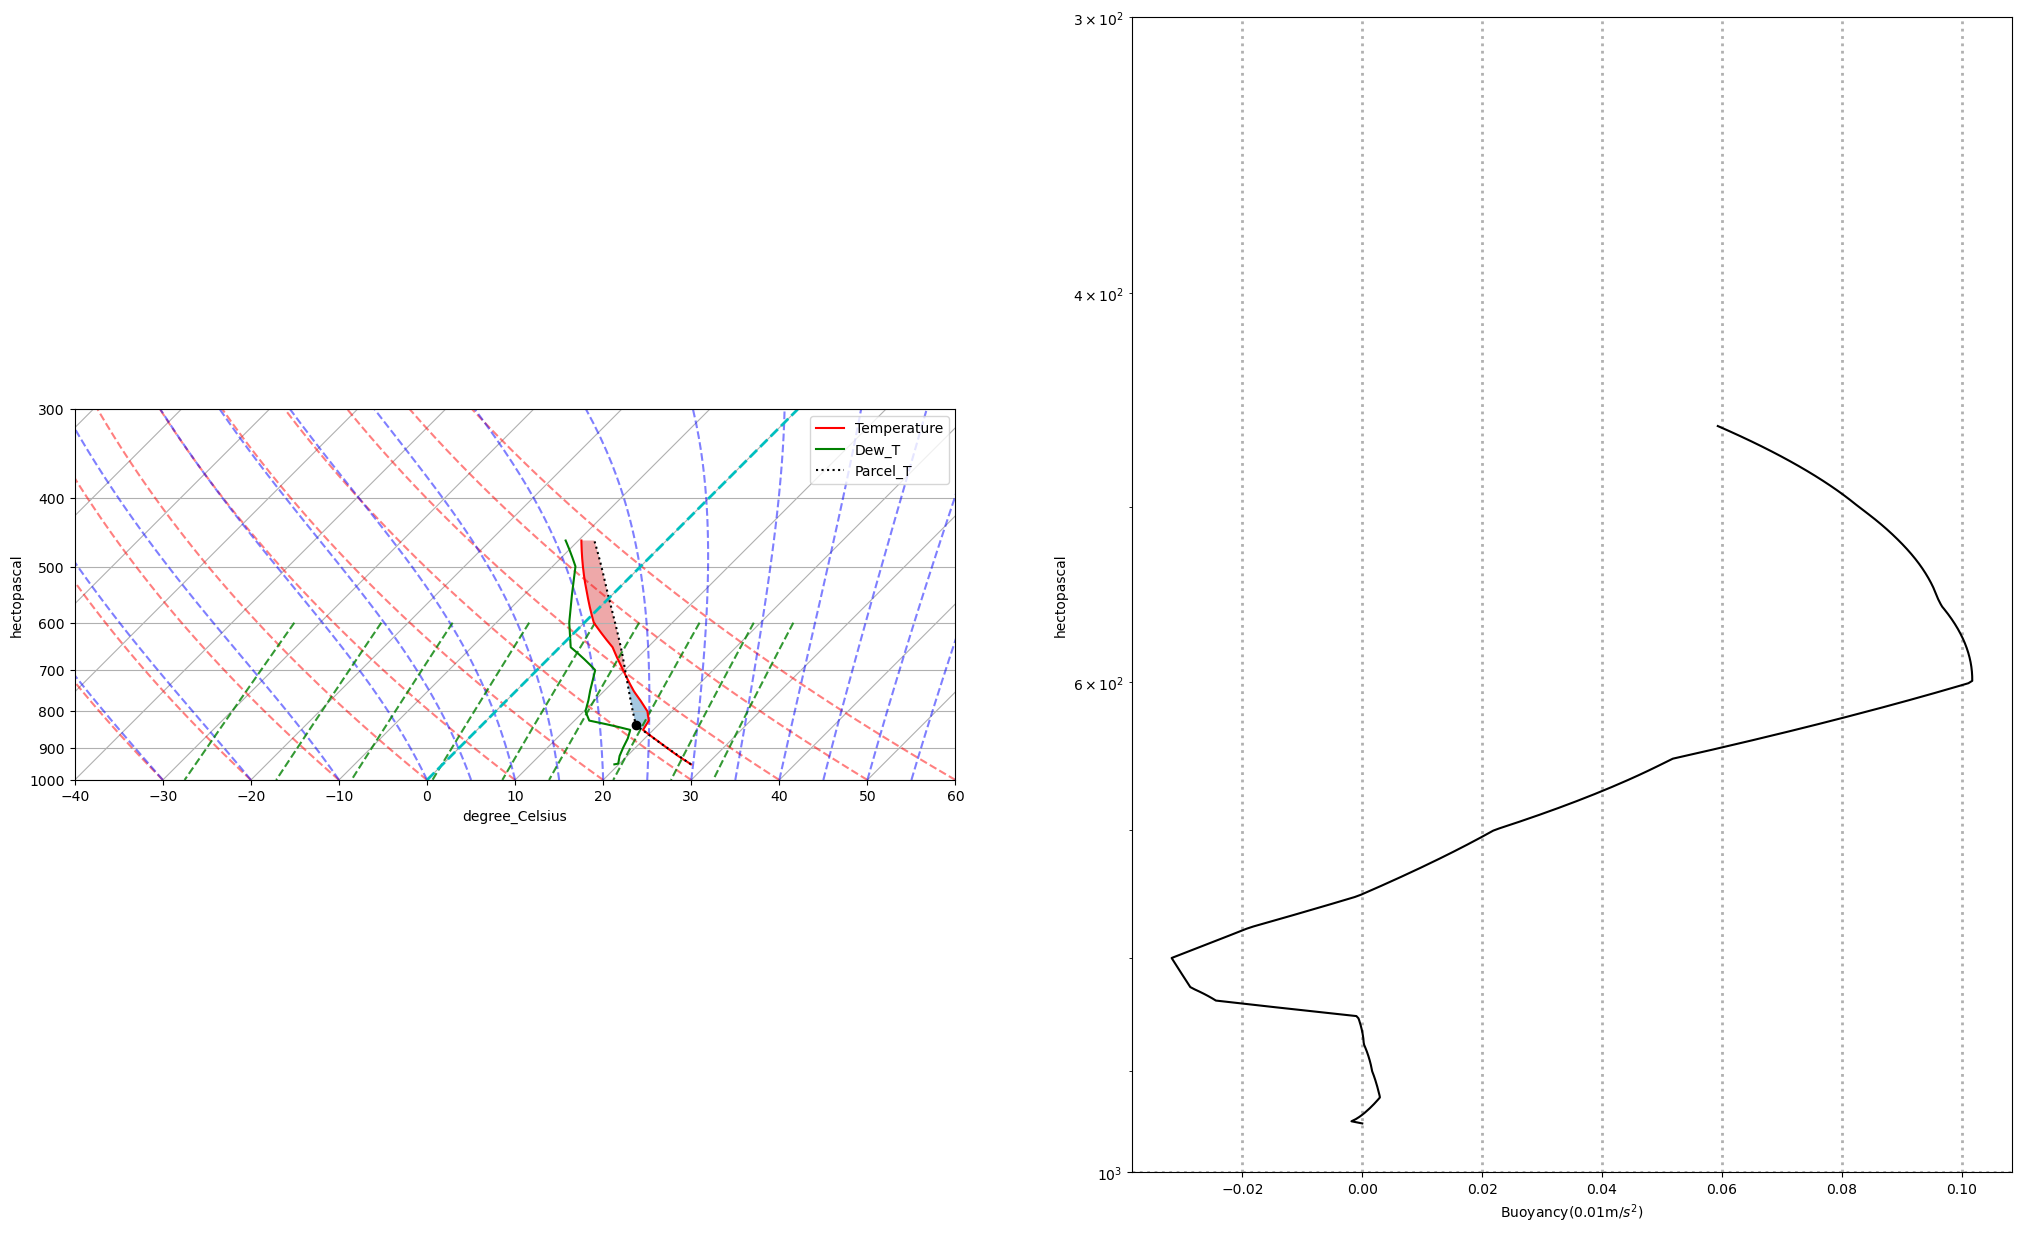

lfc: 748.4376247692475 hectopascal
corrected br integrated: 91.18818620926766 joule / kilogram


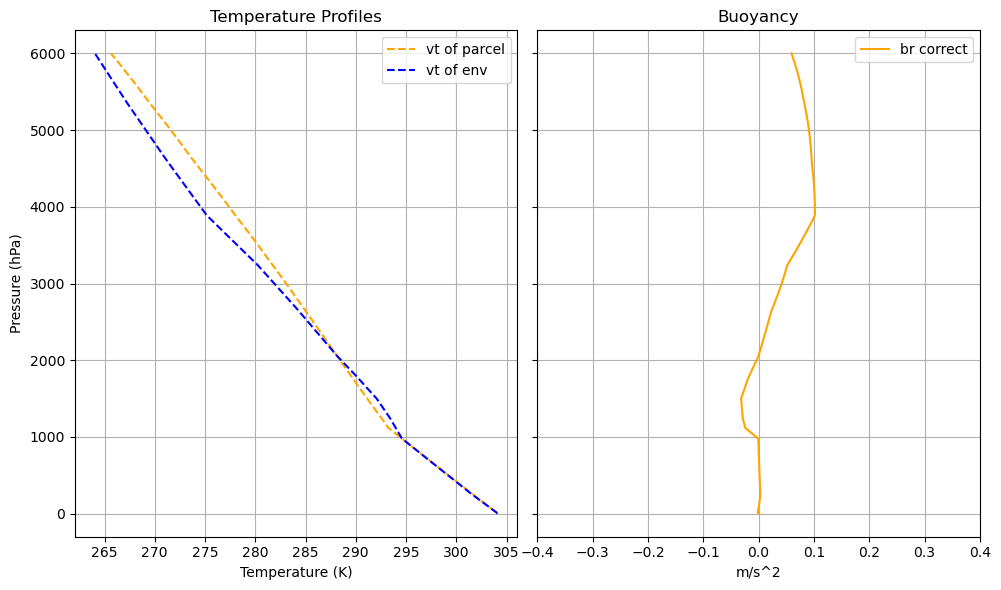

In [67]:
g = 9.80665

p = interpolated_pressure[day_idx, :, lat_idx, lon_idx]

# in g/kg

q = interpolated_q[day_idx, :, lat_idx, lon_idx]

qfit = interpolated_qfit[day_idx, :, lat_idx, lon_idx]

t = interpolated_t[day_idx, :, lat_idx, lon_idx]

alt = np.arange(0, 6000 + 20, 20)

### create a mixed_parcel using bottom 1km, since qfit and q are equivalent from 0 -> 2km, 

### we can use the same mixed parcel for both 

p_hpa = p * units.hPa

alt_m = alt * units.meter

t_degC = t * units.degC

q_gkg = q * units('g/kg')

dewpt_degC = dewpoint_from_specific_humidity(p_hpa, q_gkg)

mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=1000 * units.meter, height=alt_m)

mp_q = specific_humidity_from_dewpoint(mp_pres, mp_dewpt) * 1000

## ammending t, q, qfit and p such that the bottom n levels now equal the mixed parcel values 

# updating temperature

t_mix = t.copy()

t_mix[0] = mp_temp.magnitude

# convert temperature to kelvin

t_mix = t_mix + 273.15

t_kelvin = t + 273.15

# updating specific humidity 

q_mix = q.copy()

q_mix[0] = mp_q.magnitude

# updating dewpoint

dewpt_mix = dewpt_degC.magnitude

dewpt_mix[0] = mp_dewpt.magnitude

br_dewpt = cal_buoyancy(t_profile = t_mix, h_profile = dewpt_mix, p_profile = p, alt_profile = alt, 
                        entrain_opt = 2, td_r_q=1)

# extract virtual temperature of parcel 

tv2_dp = br_dewpt.tv2

# extract virtual temperature of environment

tv_dp = br_dewpt.tv

# extract temperature of parcel 

tp_dp = br_dewpt.tp

br_correct_prof = br_dewpt.bp * units('m/s^2')

mask = (alt >= 2000) & (alt <= 4000)

#metpy.calc.lfc(pressure, temperature, dewpoint, parcel_temperature_profile=None, dewpoint_start=None, which='top')

lfc_pressure, lfc_temperature = lfc(
    
    pressure=p * units.hPa,
    
    temperature=tv_dp * units.K,
    
    dewpoint=dewpt_mix * units.degC,
    
    parcel_temperature_profile=tv2_dp * units.K
)

print("lfc:", lfc_pressure)

## integrate entire buoyancy profile over height 

br_correct_int = np.trapz(br_correct_prof[mask], alt[mask]*units.meter).to(units('J/kg'))

# b_gloria = (tp_dp - t_mix) * units.kelvin

pPa = p*100

# br_gloria_int = (mpconsts.Rd * (np.trapz(b_gloria[::-1], np.log(p[::-1]))))

# br_gloria_prof = g*((tp_dp - t_mix)/t_mix)

print("corrected br integrated:", br_correct_int)

# print("gloria br integrated:", br_gloria_int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# --- Left plot ---

# ax1.plot(tv2_q, p, label='tvp with q', color='blue', linestyle='--')

ax1.plot(tv2_dp, alt, label='vt of parcel', linestyle='--', color='orange')

# ax1.plot(tp_dp, p, label='tp with dp', color='blue')

ax1.plot(tv_dp, alt, label='vt of env', color='blue', linestyle='--')

# ax1.plot(tp_dp, alt, label='tp with dp', color='orange')

# ax1.plot(t_mix, alt, label='te', color='blue')

# ax1.plot(t+273.15, p, label='te (non-mix)', color='blue')

# ax1.plot(tp_dp, p, label='tp with dp', color='green')

# ax1.plot(tv_q, p, label='tve with q', linestyle='--', color='blue')

# ax1.plot(tv_dp, p, label='tve with dp', linestyle='--', color='green')

ax1.set_title('Temperature Profiles')

ax1.set_xlabel('Temperature (K)')

ax1.set_ylabel('Pressure (hPa)')

ax1.legend()

ax1.grid()

# --- Right plot ---

ax2.plot(br_correct_prof, alt, color='orange', label='br correct')

# ax2.plot(br_gloria_prof, alt, color='blue', label='br gloria')

# ax2.plot(br_q_error.bp, p, color='red', label='br with tp')

ax2.set_title('Buoyancy')

ax2.set_xlabel('m/s^2')

ax2.legend()

ax2.grid()

plt.tight_layout()

# plt.gca().invert_yaxis()

plt.xlim(-0.4,0.4)

plt.show()

#corrected br integrated: 10.735558721330571 joule / kilogram

#gloria br integrated: -15.423559884040822 joule / kilogram

In [61]:
# g = 9.80665

# p = interpolated_pressure[day_idx, :, lat_idx, lon_idx]

# # in g/kg

# q = interpolated_q[day_idx, :, lat_idx, lon_idx]

# t = interpolated_t[day_idx, :, lat_idx, lon_idx]

# alt = np.arange(0, 6000 + 20, 20)

# ### create a mixed_parcel using bottom 1km, since qfit and q are equivalent from 0 -> 2km, 

# ### we can use the same mixed parcel for both 

# p_hpa = p * units.hPa

# alt_m = alt * units.meter

# t_degC = t * units.degC

# q_gkg = q * units('g/kg')

# dewpt_degC = dewpoint_from_specific_humidity(p_hpa, q_gkg)

# mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=1000 * units.meter, height=alt_m)

# mp_q = specific_humidity_from_dewpoint(mp_pres, mp_dewpt) * 1000

# ## ammending t, q, qfit and p such that the bottom n levels now equal the mixed parcel values 

# # updating temperature

# t_mix = t.copy()

# t_mix[0] = mp_temp.magnitude

# # convert temperature to kelvin

# t_mix = t_mix + 273.15

# t_kelvin = t + 273.15

# # updating specific humidity 

# q_mix = q.copy()

# q_mix[0] = mp_q.magnitude

# # updating dewpoint

# dewpt_mix = dewpt_degC.magnitude

# dewpt_mix[0] = mp_dewpt.magnitude

# br_dewpt = cal_buoyancy(t_profile = t_mix, h_profile = dewpt_mix, p_profile = p, alt_profile = alt, 
#                         entrain_opt = 2, td_r_q=1)

# # extract virtual temperature of parcel 

# tv2_dp = br_dewpt.tv2

# # extract virtual temperature of environment

# tv_dp = br_dewpt.tv

# lfc_pressure, lfc_temperature = lfc(
    
#     pressure=p * units.hPa,
    
#     temperature=tv_dp * units.K,
    
#     dewpoint=dewpt_mix * units.degC,
    
#     parcel_temperature_profile=tv2_dp * units.K
# )

# print(lfc_pressure)

# lfc_p_hpa = lfc_pressure.m  # just the number

# lfc_alt = np.interp(lfc_p_hpa, p[::-1], alt[::-1])

# print(lfc_alt)

### compare entrainment rates

In [799]:
# ## select sample day & location 

# day_idx = 30

# lat_idx = -3

# lon_idx = -10

# print(times[day_idx], lats[lat_idx], lons[lon_idx])

# g = 9.80665

# p = interpolated_pressure[day_idx, :, lat_idx, lon_idx].compute()

# # in g/kg

# q = interpolated_q[day_idx, :, lat_idx, lon_idx].compute()

# t = interpolated_t[day_idx, :, lat_idx, lon_idx].compute()

# alt = np.arange(0, 4000 + 20, 20)

# ### create a mixed_parcel using bottom 1km, since qfit and q are equivalent from 0 -> 2km, 

# ### we can use the same mixed parcel for both 

# p_hpa = p * units.hPa

# alt_m = alt * units.meter

# t_degC = t * units.degC

# q_gkg = q * units('g/kg')

# dewpt_degC = dewpoint_from_specific_humidity(p_hpa, q_gkg)

# mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=1000 * units.meter, height=alt_m)

# mp_q = specific_humidity_from_dewpoint(mp_pres, mp_dewpt) * 1000

# ## ammending t, q, qfit and p such that the bottom n levels now equal the mixed parcel values 

# # updating temperature

# t_mix = t.copy()

# t_mix[0] = mp_temp.magnitude

# # convert temperature to kelvin

# t_mix = t_mix + 273.15

# t_kelvin = t + 273.15

# # updating specific humidity 

# q_mix = q.copy()

# q_mix[0] = mp_q.magnitude

# # updating dewpoint

# dewpt_mix = dewpt_degC.magnitude

# dewpt_mix[0] = mp_dewpt.magnitude

# br_dia = cal_buoyancy(t_profile = t_mix, h_profile = dewpt_mix, p_profile = p, alt_profile = alt, 
#                         entrain_opt = 2, td_r_q=1)

# br_no_mixing = cal_buoyancy(t_profile = t_mix, h_profile = dewpt_mix, p_profile = p, alt_profile = alt, 
#                         entrain_opt = 0, td_r_q=1)

# br_constant = cal_buoyancy(t_profile = t_mix, h_profile = dewpt_mix, p_profile = p, alt_profile = alt, 
#                         entrain_opt = 1, td_r_q=1)

# fig, ax = plt.subplots(figsize=(6, 6))

# ax.plot(br_dia.bp, alt, color='orange', label='br DIA')

# ax.plot(br_constant.bp, alt, color='green', label='br constant mixing')

# ax.plot(br_no_mixing.bp, alt, color='blue', label='br no mixing')

# ax.set_title('Buoyancy Comparison')

# ax.set_xlabel('m/s²')

# ax.set_ylabel('Altitude (m)')

# ax.legend()

# ax.grid()

# ax.set_xlim(-0.4, 0.4)

# plt.tight_layout()

# plt.show()

### compare q profiles and associated buoyancy using DIA

In [800]:
# ## select sample day & location 

# day_idx = 127

# lat_idx = -3

# lon_idx = -10

# print(times[day_idx], lats[lat_idx], lons[lon_idx])

# g = 9.80665

# p = interpolated_pressure[day_idx, :, lat_idx, lon_idx].compute()

# # in g/kg

# q = interpolated_q[day_idx, :, lat_idx, lon_idx].compute()

# t = interpolated_t[day_idx, :, lat_idx, lon_idx].compute()

# alt = np.arange(0, 4000 + 20, 20)

# ### create a mixed_parcel using bottom 1km, since qfit and q are equivalent from 0 -> 2km, 

# ### we can use the same mixed parcel for both 

# p_hpa = p * units.hPa

# alt_m = alt * units.meter

# t_degC = t * units.degC

# q_gkg = q * units('g/kg')

# dewpt_degC = dewpoint_from_specific_humidity(p_hpa, q_gkg)

# mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=1000 * units.meter, height=alt_m)

# mp_q = specific_humidity_from_dewpoint(mp_pres, mp_dewpt) * 1000

# ## ammending t, q, qfit and p such that the bottom n levels now equal the mixed parcel values 

# # updating temperature

# t_mix = t.copy()

# t_mix[0] = mp_temp.magnitude

# # convert temperature to kelvin

# t_mix = t_mix + 273.15

# t_kelvin = t + 273.15

# # updating specific humidity 

# q_mix = q.copy()

# q_mix[0] = mp_q.magnitude

# # --- choose humidity test values (g/kg) ---
# very_dry_value  = 0.5    # example: extremely dry

# very_moist_value = 20  # example: very moist through the column

# # --- normal humidity (what you already set up) ---
# q_normal = q_mix.copy()   # g/kg

# # --- construct dry and moist test profiles ---
# q_dry   = np.full_like(q_normal, very_dry_value)       # g/kg

# q_moist = np.full_like(q_normal, very_moist_value)     # g/kg

# # --- convert to pint units for dewpoint conversion ---

# q_normal_units = q_normal * units('g/kg')

# q_dry_units    = q_dry    * units('g/kg')

# q_moist_units  = q_moist  * units('g/kg')

# # --- compute dewpoints from specific humidity ---

# dewpt_normal = dewpoint_from_specific_humidity(p_hpa, q_normal_units).magnitude

# dewpt_dry    = dewpoint_from_specific_humidity(p_hpa, q_dry_units).magnitude

# dewpt_moist  = dewpoint_from_specific_humidity(p_hpa, q_moist_units).magnitude

# # --- compute buoyancy for all three humidity profiles ---
# br_normal = cal_buoyancy(t_profile=t_mix, h_profile=dewpt_normal,
#                          p_profile=p, alt_profile=alt,
#                          entrain_opt=2, td_r_q=1)

# # br_dry = cal_buoyancy(t_profile=t_mix, h_profile=dewpt_dry,
# #                       p_profile=p, alt_profile=alt,
# #                       entrain_opt=2, td_r_q=1)

# # br_moist = cal_buoyancy(t_profile=t_mix, h_profile=dewpt_moist,
# #                         p_profile=p, alt_profile=alt,
# #                         entrain_opt=2, td_r_q=1)

# # # --- plot the three buoyancy profiles ---
# # fig, ax = plt.subplots(figsize=(6, 7))

# # ax.plot(br_normal.bp, alt, label='normal q', linewidth=2)

# # ax.plot(br_dry.bp,    alt, label='very dry q', linestyle='--', linewidth=2)

# # ax.plot(br_moist.bp,  alt, label='very moist q', linestyle=':', linewidth=2)

# # ax.set_title('Buoyancy Profiles: Normal vs Dry vs Moist Humidity')

# # ax.set_xlabel('Buoyancy (m/s²)')

# # ax.set_ylabel('Altitude (m)')

# # ax.legend()

# # ax.grid()

# # ax.set_xlim(-0.4, 0.4)

# # plt.tight_layout()

# # plt.show()

##### script below generates 100 random samples given day, lat, lon and produces profiles of parcel temp (and tv) and environmental temp (and tev), as well as how using temp vs. virtual temp impacts the buoyancy profiles and total integrated buoyancy 

In [801]:
# # --- setup constants ---

# g = 9.81  # m/s^2

# n_cases = 10  # number of random samples

# np.random.seed(42)  # optional, for reproducibility

# # assume these are your data dimensions

# n_days = interpolated_pressure.shape[0]

# n_levels = interpolated_pressure.shape[1]

# n_lat = interpolated_pressure.shape[2]

# n_lon = interpolated_pressure.shape[3]

# alt = np.arange(0, 4000 + 20, 20)

# # --- random sampling loop ---
# for i in range(n_cases):
    
#     day_idx = np.random.randint(0, n_days)
    
#     lat_idx = np.random.randint(0, n_lat)
    
#     lon_idx = np.random.randint(0, n_lon)

#     # --- extract profiles ---
    
#     p = interpolated_pressure[day_idx, :, lat_idx, lon_idx].compute()
    
#     q = interpolated_q[day_idx, :, lat_idx, lon_idx].compute()
    
#     qfit = interpolated_qfit[day_idx, :, lat_idx, lon_idx].compute()
    
#     t = interpolated_t[day_idx, :, lat_idx, lon_idx].compute()

#     # convert units
    
#     p_hpa = p * units.hPa
    
#     alt_m = alt * units.meter
    
#     t_degC = t * units.degC
    
#     q_gkg = q * units('g/kg')

#     # --- mixed parcel calculations ---
    
#     dewpt_degC = dewpoint_from_specific_humidity(p_hpa, q_gkg)
    
#     mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC,
#                                               depth=1000 * units.meter,
#                                               height=alt_m)
#     mp_q = specific_humidity_from_dewpoint(mp_pres, mp_dewpt) * 1000  # g/kg

#     # --- modify lowest level with mixed parcel values ---
    
#     t_mix = t.copy()
    
#     t_mix[0] = mp_temp.magnitude
    
#     t_mix = t_mix + 273.15  # convert to K

#     q_mix = q.copy()
    
#     q_mix_fit = qfit.copy()
    
#     q_mix[0] = mp_q.magnitude
    
#     q_mix_fit[0] = mp_q.magnitude
    
#     dewpt_mix = dewpt_degC.magnitude
    
#     dewpt_mix[0] = mp_dewpt.magnitude

#     # --- buoyancy profiles ---
    
#     br = cal_buoyancy(t_profile=t_mix, h_profile=dewpt_mix,
#                       p_profile=p, alt_profile=alt, entrain_opt=2, td_r_q=1)
    
# #     blc = cal_buoyancy(t_profile=t_mix, h_profile=q_mix_fit,
# #                        p_profile=p, alt_profile=alt, entrain_opt=2)

#     tp = br.tp #temperature of parcel
    
#     tv2 = br.tv2 #virtual temperature of parcel
    
#     tv = br.tv #virtual temperature of environment
    
#     b2 = br.bp * units('m/s^2')
    
#     b1 = g * (tp - t_mix) / t_mix

#     # --- integrate buoyancy to get J/kg ---
    
#     b2_int = np.trapz(b2, alt * units.meter).to(units('J/kg'))
    
#     b1_int = np.trapz(b1 * units('m/s^2'), alt * units.meter).to(units('J/kg'))

#     # --- plotting ---
    
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
    
#     fig.suptitle(f"Case {i+1}: day={day_idx}, lat={lat_idx}, lon={lon_idx}")

#     # left: temperature profiles
    
#     ax1.plot(tp, alt, label='tp', linestyle='--', color='blue')
    
#     ax1.plot(tv2, alt, label='tpv', linestyle='--', color='green')
    
#     ax1.plot(t_mix, alt, label='te', color='blue')
    
#     ax1.plot(tv, alt, label='tev', color='green')
    
#     ax1.set_title('Temperature Profiles')
    
#     ax1.set_xlabel('Temperature (K)')
    
#     ax1.set_ylabel('Altitude (m)')
    
#     ax1.legend()
    
#     ax1.grid()

#     # right: buoyancy
    
#     ax2.plot(b2, alt, label=f'tv (int={b2_int:.2f})', linestyle='--', color='green')
    
#     ax2.plot(b1, alt, label=f't (int={b1_int:.2f})', linestyle='--', color='blue')
    
#     ax2.set_title('Buoyancy Comparison')
    
#     ax2.set_xlabel('m/s²')
    
#     ax2.legend()
    
#     ax2.grid()

#     plt.tight_layout()
    
#     plt.xlim(-0.25, 0.25)
    
#     plt.show()


In [802]:
# tidx = 126

# latidx = -1

# lonidx = -1

# p = interpolated_pressure[tidx, :, latidx, lonidx].compute()

# # in g/kg

# q = interpolated_q[tidx, :, latidx, lonidx].compute()

# qfit = interpolated_qfit[tidx, :, latidx, lonidx].compute()

# # in deg C

# t = interpolated_t[tidx, :, latidx, lonidx].compute()

# # in meters 

# ### create a mixed_parcel using bottom 1km, since qfit and q are equivalent from 0 -> 2km, 
# ### we can use the same mixed parcel for both 

# p_hpa = p * units.hPa

# alt_m = alt * units.meter

# t_degC = t * units.degC

# q_gkg = q * units('g/kg')

# qfit_gkg = qfit * units('g/kg')

# dewpt_degC_from_q = dewpoint_from_specific_humidity(p_hpa, q_gkg)

# dewpt_degC_from_qfit = dewpoint_from_specific_humidity(p_hpa, qfit_gkg)

# mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC_from_q, depth=1000 * units.meter, height=alt_m)

# ## ammending t, q, qfit and p such that the bottom n levels now equal the mixed parcel values 

# # updating temperature

# t_mix = t.copy()

# t_mix[0] = mp_temp.magnitude

# # convert temperature to kelvin

# t_mix = t_mix + 273.15

# # updating for dewpoint from q

# dewpt_mix = dewpt_degC_from_q.magnitude

# dewpt_mix[0] = mp_dewpt.magnitude

# # updating for dewpoint from q fit

# dewpt_mix_fit = dewpt_degC_from_qfit.magnitude

# dewpt_mix_fit[0] = mp_dewpt.magnitude

# print(mp_dewpt)

# # temperature = Kelvin, q = g/kg

# # buoyancy given environmental t (kelvin), dewpoint, and p with first element replaced with mixed parcel value

# br = cal_buoyancy(t_profile=t_mix, h_profile=dewpt_mix, p_profile=p, alt_profile=alt, entrain_opt=2, td_r_q=1)

# # buoyancy given environmental t, qfit, and p with first element replaced with mixed parcel value

# blc = cal_buoyancy(t_profile=t_mix, h_profile=dewpt_mix_fit, p_profile=p, alt_profile=alt, entrain_opt=2, td_r_q=1)

# layer_mask = (alt >= 2000) & (alt <= 4000)

# z_layer = alt[layer_mask] * units.meter

# br_layer = br.bp[layer_mask] * units('m/s^2') 

# blc_layer = blc.bp[layer_mask] * units('m/s^2')  

# # integrate over height to get J/kg

# br_int = np.trapz(br_layer, z_layer).to(units('J/kg'))

# blc_int = np.trapz(blc_layer, z_layer).to(units('J/kg'))

# blt_int = br_int - blc_int

# print(br_int, blc_int, blt_int)

# plt.plot(br.bp, alt, label='br')

# plt.plot(blc.bp, alt, label='blc')

# plt.xlim(-0.5, 0.5)

# plt.xlabel("m/s^2")

# plt.legend()

# plt.grid()

# plt.show()